In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jacfwd, vmap
import numpy as np
import matplotlib.pyplot as plt
key = jax.random.PRNGKey(42)
np.random.seed(42)

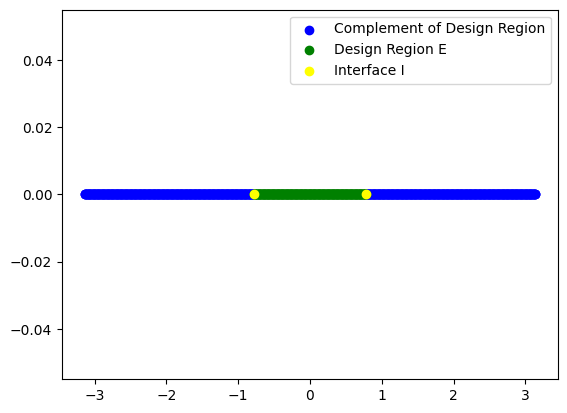

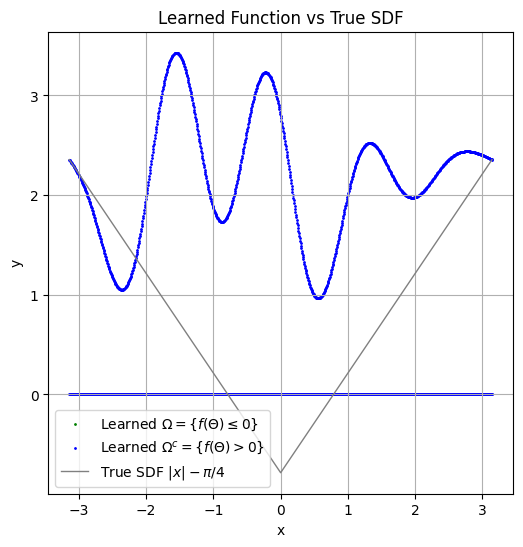

In [ ]:
class Domain:
    def __init__(self, x_left=-np.pi, x_right=np.pi, num_points=1001):
        self.points = jnp.linspace(x_left, x_right, num_points)

class DesignRegion:
    def __init__(self, domain, x_left=-np.pi/4, x_right=np.pi/4):
        # Create mask for points that are within (x_left, x_right)
        in_design_region_mask = (domain.points >= x_left) & (domain.points <= x_right)

        self.mask = in_design_region_mask

        # Save indices of points inside the design region
        self.indices = jnp.where(in_design_region_mask)[0]

        # Save indices of points outside the design region
        self.indices_complement = jnp.where(~in_design_region_mask)[0]

class Interface:
    def __init__(self, domain, x_left=-np.pi/4, x_right=np.pi/4, tol=1e-6):
        section_1_mask = jnp.abs(domain.points - x_left) < tol
        section_2_mask = jnp.abs(domain.points - x_right) < tol

        self.mask = section_1_mask | section_2_mask

        # Combine indices of boundary points
        self.indices_boundary = jnp.where(self.mask)[0]
        self.indices_non_boundary = jnp.where(~self.mask)[0]

class FourierFeatures:
    def __init__(self, K=16, x_left=-np.pi, x_right=np.pi):
        """
        Args:
            K: Maximum frequency index (positive integers only).
            x_left, x_right: Left and right boundaries of the domain.
        """
        self.K = K  # Maximum frequency index
        self.x_left = x_left
        self.x_right = x_right
        self.L = x_right - x_left  # Domain length

        # Initialize parameters for the sine basis
        self.theta = jnp.ones(K) * jax.random.normal(jax.random.PRNGKey(0), shape=(K,))  # random init
        self.num_params = K

    def basis_functions(self, x):
        """Compute all sine basis functions at the point(s) x."""
        return jnp.stack([
            jnp.sqrt(2 / self.L) * jnp.sin(k * jnp.pi * (x - self.x_left) / self.L)
            for k in range(1, self.K + 1)
        ], axis=-1)  # Shape: (num_points, K)

    def basis_gradients(self, x):
        """Compute all gradients of the sine basis functions at the point(s) x."""
        return jnp.stack([
            jnp.sqrt(2 / self.L) * (k * jnp.pi / self.L) * jnp.cos(k * jnp.pi * (x - self.x_left) / self.L)
            for k in range(1, self.K + 1)
        ], axis=-1)  # Shape: (num_points, K)

    def basis_second_derivatives(self, x):
        """Compute all second derivatives of the sine basis functions at the point(s) x."""
        return jnp.stack([
            -jnp.sqrt(2 / self.L) * (k * jnp.pi / self.L)**2 * jnp.sin(k * jnp.pi * (x - self.x_left) / self.L)
            for k in range(1, self.K + 1)
        ], axis=-1)  # Shape: (num_points, K)

    def forward(self, x, theta):
        """Compute the Fourier sine series output at the point(s) x."""
        basis_evals = self.basis_functions(x)
        return jnp.dot(basis_evals, theta) + 3/4 * jnp.pi  # Shape: (num_points,)

    def gradient(self, x, theta):
        """Compute the gradient of the Fourier sine series at the point(s) x."""
        basis_grads = self.basis_gradients(x)
        return jnp.dot(basis_grads, theta)  # Shape: (num_points,)

    def laplace(self, x, theta):
        """Compute the Laplacian of the Fourier sine series at the point(s) x."""
        basis_second_derivatives = self.basis_second_derivatives(x)
        return jnp.dot(basis_second_derivatives, theta)  # Shape: (num_points,)



# Initialize domain, model, and design region
domain = Domain(num_points=1001)  # Odd number important so that interface isn't empty
points = domain.points
design_region = DesignRegion(domain)
interface = Interface(domain)

# Initialize FourierFeatures model
K=10
model = FourierFeatures(K)
design_region_points = points[design_region.indices]
interface_boundary_points = points[interface.indices_boundary]
design_region_complement_points = points[design_region.indices_complement]
plt.scatter(design_region_complement_points, np.zeros_like(design_region_complement_points), label='Complement of Design Region', color='blue')
plt.scatter(design_region_points, np.zeros_like(design_region_points), label='Design Region E', color='green')
plt.scatter(interface_boundary_points, np.zeros_like(interface_boundary_points), label='Interface I', color='yellow')
plt.legend(loc="upper right")

def plot_learned_sdf(model, domain, points, theta):
    # Compute model outputs
    output = model.forward(points, theta)

    # Separate sublevel and superlevel sets
    sublevel_points = domain.points[output <= 0]
    superlevel_points = domain.points[output > 0]

    # Compute the true SDF
    true_sdf = jnp.abs(points) - jnp.pi / 4

    # Plot learned SDF
    plt.figure(figsize=(6, 6))
    plt.scatter(sublevel_points, output[output <= 0], s=1, color='green')
    plt.scatter(superlevel_points, output[output > 0], s=1, color='blue')
    plt.scatter(sublevel_points, jnp.zeros_like(sublevel_points), s=1, color='green', label="Learned $\Omega = \{f( \Theta )\leq 0\}$")
    plt.scatter(superlevel_points, jnp.zeros_like(superlevel_points), s=1, color='blue', label="Learned $\Omega^c = \{f( \Theta ) > 0\}$")

    # Plot true SDF as a fine line
    plt.plot(points, true_sdf, color='gray', linewidth=1, label="True SDF $|x| - \pi/4$")

    # Styling the plot
    plt.title("Learned Function vs True SDF")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()


plot_learned_sdf(model, domain, domain.points, model.theta)


In [ ]:
def calculate_loss_interface(output, interface):
    # Extract boundary output
    boundary_output = output[interface.indices_boundary]

    # Loss on boundary (mean of squared values)
    return 0.5*jnp.mean(boundary_output**2)

def calculate_loss_eikonal(output, points, theta):
    # Define a function to compute the gradient for each input
    def gradient_norm(x):
        return jnp.abs(model.gradient(x, theta))

    # Vectorize the gradient computation across all input points
    grad_abs = vmap(gradient_norm)(points)

    # Compute the eikonal loss (mean squared difference from 1)
    eikonal_term = (grad_abs - 1.0) ** 2

    return 0.5*jnp.mean(eikonal_term)*2*jnp.pi


def calculate_loss_laplacian(output, points, theta):
    # Define a function to compute the gradient for each input
    def laplace(x):
        return model.laplace(x, theta)

    # Vectorize the laplace computation across all input points
    laplace_squared = vmap(laplace)(points) ** 2

    return 0.5*jnp.mean(laplace_squared)*2*jnp.pi


def target_function(x):
    """ Target function |x| - pi/4. """
    return jnp.abs(x) - np.pi / 4

def target_function_gradient(x):
    """ Derivative of the target function |x| - pi/4. """
    return jnp.sign(x)

def error(model, points, theta):
    """ Compute the Sobolev H1 norm between the model output and the function |x| - pi/4. """

    output = model.forward(points, theta)
    target_values = target_function(points)

    output_gradient = model.gradient(points, theta)
    target_gradient = target_function_gradient(points)

    error_h1 = jnp.mean((output - target_values) ** 2 + (output_gradient - target_gradient) ** 2)

    return error_h1

In [ ]:
from jax.scipy.linalg import eigh
from jax import hessian

# Approximate Interface Hessian
def calculate_A_interface(theta):
    basis_functions_interface = model.basis_functions(points[interface.indices_boundary])
    A_interface = 0.5*basis_functions_interface.T @ basis_functions_interface
    eigenvalues = eigh(A_interface, eigvals_only=True)
    return A_interface, eigenvalues

# Approximate Eikonal Hessian
def calculate_A_eikonal(theta):
    basis_gradients = model.basis_gradients(domain.points)

    def gradient_norm(x):
        return jnp.abs(model.gradient(x, theta))
    grad_norm = vmap(gradient_norm)(points)

    # This is still the old weight dependent A_k, need to update to Hessian
    # weight_factor = (1-1/grad_norm)
    weight_factor = jnp.ones(basis_gradients.shape[0])
    weight_factor = weight_factor.at[0].set(weight_factor[0] / 2)
    weight_factor = weight_factor.at[-1].set(weight_factor[-1] / 2)
    A_eikonal = weight_factor * basis_gradients.T @ basis_gradients / basis_gradients.shape[0] * 2 * np.pi
    eigenvalues = eigh(A_eikonal, eigvals_only=True)
    return A_eikonal, eigenvalues

# Approximate Laplace Hessian
def calculate_A_laplace(theta):
    basis_laplace = model.basis_second_derivatives(domain.points)
    weight_factor = jnp.ones(basis_laplace.shape[0])
    weight_factor = weight_factor.at[0].set(weight_factor[0] / 2)
    weight_factor = weight_factor.at[-1].set(weight_factor[-1] / 2)
    A_eikonal = weight_factor * basis_laplace.T @ basis_laplace / basis_laplace.shape[0] * 2 * np.pi
    eigenvalues = eigh(A_eikonal, eigvals_only=True)
    return A_eikonal, eigenvalues


print("Frobenius norm of difference between Hessian with autodiff and my calculations")
A_interface, _ = calculate_A_interface(model.theta)
Hessian_interface = hessian(lambda t: calculate_loss_interface(model.forward(points, t), interface))(model.theta)
print("Interface: ", jnp.linalg.norm(A_interface - Hessian_interface, ord="fro"))
A_eikonal, _ = calculate_A_eikonal(model.theta)
# A_eikonal = jnp.diag(jnp.array([k**2/4 for k in range(1, K+1)]))
Hessian_eikonal = hessian(lambda t: calculate_loss_eikonal(model.forward(points, t), points, t))(model.theta)
print("Eikonal: ", jnp.linalg.norm(A_eikonal - Hessian_eikonal, ord="fro"))
A_laplace, _ = calculate_A_laplace(model.theta)
# A_laplace = jnp.diag(jnp.array([k**4/16 for k in range(1,K+1)]))
Hessian_laplace = hessian(lambda t: calculate_loss_laplacian(model.forward(points, t), points, t))(model.theta)
print("Laplace: ", jnp.linalg.norm(A_laplace - Hessian_laplace, ord="fro"))

Frobenius norm of difference between Hessian with autodiff and my calculations
Interface:  5.8559284e-08
Eikonal:  0.13736652
Laplace:  0.0001666325


Epoch 0, Total Loss: 5.05167293548584, Interface Loss: 1.2526109218597412, Eikonal Loss: 8.21680736541748, Laplace Loss: 297.7381286621094
Epoch 100, Total Loss: 1.3037134408950806, Interface Loss: 0.9459452033042908, Eikonal Loss: 0.9168752431869507, Laplace Loss: 26.60807228088379
Epoch 200, Total Loss: 0.7958796620368958, Interface Loss: 0.52143794298172, Eikonal Loss: 0.8161339163780212, Laplace Loss: 19.2828369140625
Epoch 300, Total Loss: 0.5473319292068481, Interface Loss: 0.3074706792831421, Eikonal Loss: 0.9124668836593628, Laplace Loss: 14.861456871032715
Epoch 400, Total Loss: 0.3764970004558563, Interface Loss: 0.18840967118740082, Eikonal Loss: 0.7807965278625488, Laplace Loss: 11.000768661499023
Epoch 500, Total Loss: 0.2871488928794861, Interface Loss: 0.1170790046453476, Eikonal Loss: 0.7762001156806946, Laplace Loss: 9.244987487792969
Epoch 600, Total Loss: 0.23195673525333405, Interface Loss: 0.07582806795835495, Eikonal Loss: 0.7807008624076843, Laplace Loss: 7.80585

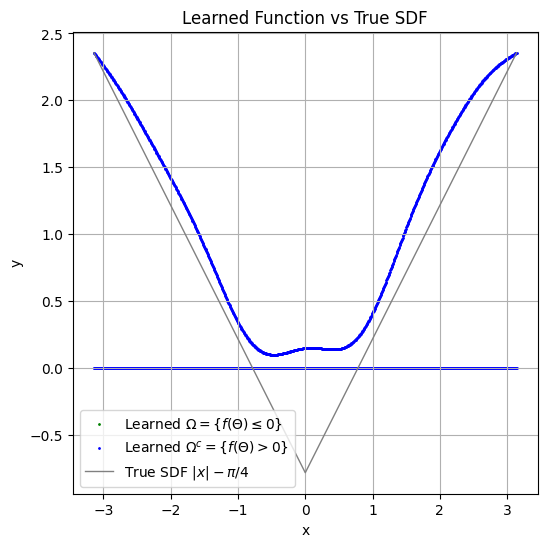

Text(0.5, 1.0, 'Training Loss')

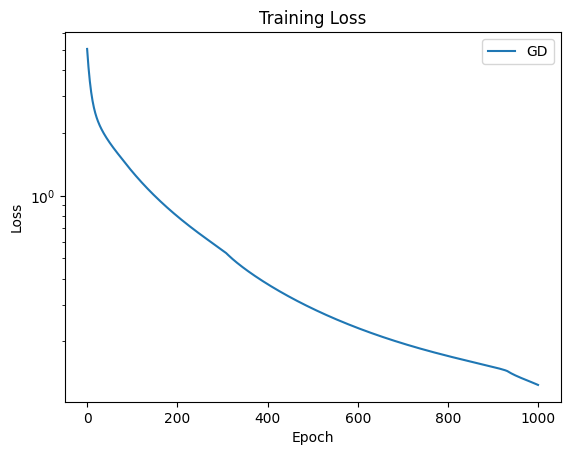

In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jit

K=10
points = domain.points
model = FourierFeatures(K)


# Training loop parameters
num_epochs = 1000
losses_gd = jnp.zeros(num_epochs)
learning_rate = 0.01
h_interface, h_eikonal, h_laplace = jnp.array([10,  1,  1])/10 #These are best parameters so far
h_interface, h_eikonal, h_laplace = jnp.array([10,  1,  0.1])/10 #Interesting because GD fails and precond best

@jit
def compute_total_loss(theta, points):
    output = model.forward(points, theta)

    # Calculate each individual loss
    interface_loss = calculate_loss_interface(output, interface)
    eikonal_loss = calculate_loss_eikonal(output, points, theta)
    laplace_loss = calculate_loss_laplacian(output, points, theta)

    # Combine the losses with appropriate weighting
    total_loss = h_interface * interface_loss + h_eikonal * eikonal_loss + h_laplace * laplace_loss

    return total_loss, interface_loss, eikonal_loss, laplace_loss

@jit
def compute_loss_and_grads(theta, points):
    total_loss, interface_loss, eikonal_loss, laplace_loss = compute_total_loss(theta, points)
    grads = grad(lambda t: compute_total_loss(t, points)[0])(theta)
    return total_loss, interface_loss, eikonal_loss, laplace_loss, grads

for epoch in range(num_epochs):
    # Compute loss and gradients
    theta = model.theta
    total_loss, interface_loss, eikonal_loss, laplace_loss, grads = compute_loss_and_grads(theta, points)
    losses_gd = losses_gd.at[epoch].set(total_loss)

    # Update parameters
    model.theta = model.theta - learning_rate * grads

    # Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Total Loss: {total_loss}, Interface Loss: {interface_loss}, Eikonal Loss: {eikonal_loss}, Laplace Loss: {laplace_loss}")

print("Training complete.")
plot_learned_sdf(model, domain, domain.points, model.theta)
plt.plot(losses_gd, label="GD")
plt.legend()
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

Epoch 0, Total Loss: 5.05167293548584, Interface Loss: 1.2526109218597412, Eikonal Loss: 8.21680736541748, Laplace Loss: 297.7381286621094
Epoch 100, Total Loss: 0.9933483600616455, Interface Loss: 0.6656129956245422, Eikonal Loss: 0.9993645548820496, Laplace Loss: 22.779891967773438
Epoch 200, Total Loss: 0.5393079519271851, Interface Loss: 0.29639413952827454, Eikonal Loss: 0.919029951095581, Laplace Loss: 15.101079940795898
Epoch 300, Total Loss: 0.3518385589122772, Interface Loss: 0.13996882736682892, Eikonal Loss: 0.9989585280418396, Laplace Loss: 11.197388648986816
Epoch 400, Total Loss: 0.24744202196598053, Interface Loss: 0.07816462963819504, Eikonal Loss: 0.9941720366477966, Laplace Loss: 6.986018180847168
Epoch 500, Total Loss: 0.1607615053653717, Interface Loss: 0.04167232662439346, Eikonal Loss: 0.7349303960800171, Laplace Loss: 4.559613227844238
Epoch 600, Total Loss: 0.08922079205513, Interface Loss: 0.02439172938466072, Eikonal Loss: 0.43975961208343506, Laplace Loss: 2.

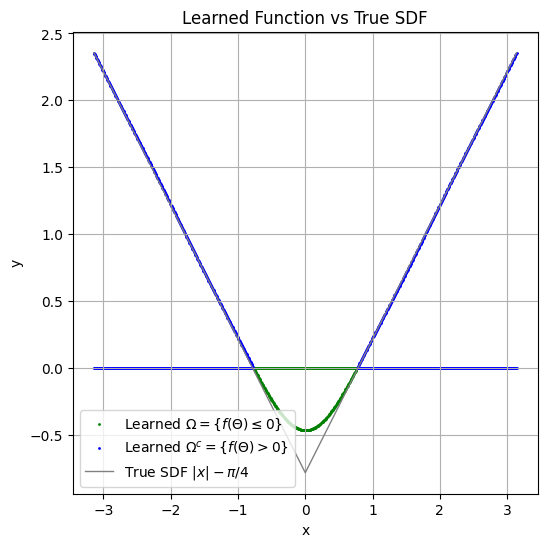

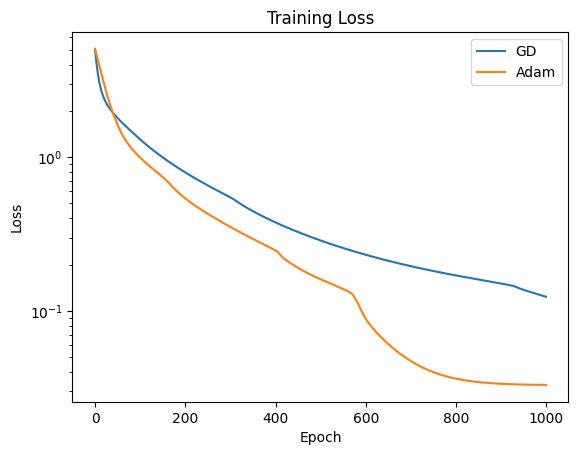

In [ ]:
model = FourierFeatures(K)

# Initialize Adam parameters
m = jnp.zeros_like(model.theta)  # First moment
v = jnp.zeros_like(model.theta)  # Second moment
beta1, beta2 = 0.9, 0.999  # Decay rates
epsilon = 1e-8  # Smoothing term


# Storage for losses
losses_adam = jnp.zeros(num_epochs)

# Training loop
for epoch in range(num_epochs):
    # Compute loss and gradients
    theta = model.theta
    total_loss, interface_loss, eikonal_loss, laplace_loss, grads = compute_loss_and_grads(theta, points)
    if epoch < 0:
        model.theta = model.theta - learning_rate * grads
    else:
    # Adam optimizer update
        m = beta1 * m + (1 - beta1) * grads
        v = beta2 * v + (1 - beta2) * (grads ** 2)
        m_hat = m / (1 - beta1 ** (epoch + 1))
        v_hat = v / (1 - beta2 ** (epoch + 1))

        model.theta = model.theta - learning_rate * m_hat / (jnp.sqrt(v_hat) + epsilon)

    # Log loss
    losses_adam = losses_adam.at[epoch].set(total_loss)

    # Logging every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Total Loss: {total_loss}, Interface Loss: {interface_loss}, Eikonal Loss: {eikonal_loss}, Laplace Loss: {laplace_loss}")

# Plotting results
print("Training complete.")
plot_learned_sdf(model, domain, domain.points, model.theta)
plt.plot(losses_gd, label="GD")
plt.plot(losses_adam, label="Adam")
plt.legend()
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


Epoch 0, Total Loss: 5.05167293548584, Interface Loss: 1.2526109218597412, Eikonal Loss: 8.21680736541748, Laplace Loss: 297.7381286621094
Epoch 100, Total Loss: 0.917086660861969, Interface Loss: 0.21776919066905975, Eikonal Loss: 1.036842703819275, Laplace Loss: 59.563323974609375
Epoch 200, Total Loss: 0.26700204610824585, Interface Loss: 0.04128352925181389, Eikonal Loss: 0.6586785912513733, Laplace Loss: 15.985065460205078
Epoch 300, Total Loss: 0.11376181244850159, Interface Loss: 0.007532024290412664, Eikonal Loss: 0.5383921265602112, Laplace Loss: 5.2390570640563965
Epoch 400, Total Loss: 0.0778927132487297, Interface Loss: 0.002145616803318262, Eikonal Loss: 0.5170260667800903, Laplace Loss: 2.4044482707977295
Epoch 500, Total Loss: 0.04646119102835655, Interface Loss: 0.0018280650256201625, Eikonal Loss: 0.3148692846298218, Laplace Loss: 1.314619779586792
Epoch 600, Total Loss: 0.03709208592772484, Interface Loss: 0.0010178480297327042, Eikonal Loss: 0.23408277332782745, Lapl

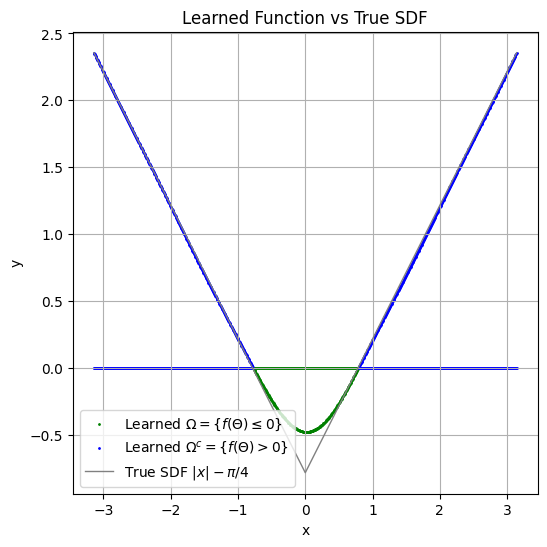

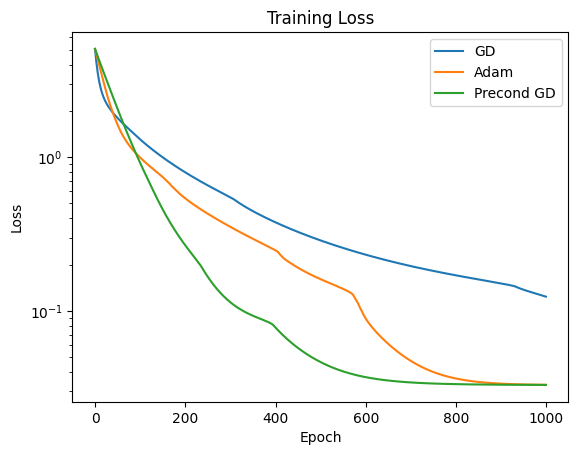

In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jit


model = FourierFeatures(K)

losses_gd_precond = jnp.zeros(num_epochs)

A_interface, _ = calculate_A_interface(model.theta)
A_laplace = jnp.diag(jnp.array([k**4/16 for k in range(1,K+1)]))
A_eikonal = jnp.diag(jnp.array([k**2/4 for k in range(1, K+1)]))
Hessian_total = h_interface*A_interface + h_eikonal*A_eikonal + h_laplace*A_laplace
# TODO do cholesky for speedup

for epoch in range(num_epochs):
    # Compute loss and gradients
    theta = model.theta

    total_loss, interface_loss, eikonal_loss, laplace_loss, grads = compute_loss_and_grads(theta, points)

    if epoch < 0:
        grads_transformed = grads
    else:
        grads_transformed = jnp.linalg.solve(Hessian_total + 1e-5 * jnp.eye(Hessian_total.shape[0]), grads)

    losses_gd_precond = losses_gd_precond.at[epoch].set(total_loss)

    # Update parameters
    model.theta = model.theta - learning_rate * grads_transformed

    # Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Total Loss: {total_loss}, Interface Loss: {interface_loss}, Eikonal Loss: {eikonal_loss}, Laplace Loss: {laplace_loss}")

# Plotting results
print("Training complete.")
plot_learned_sdf(model, domain, domain.points, model.theta)
plt.plot(losses_gd, label="GD")
plt.plot(losses_adam, label="Adam")
plt.plot(losses_gd_precond, label="Precond GD")
plt.legend()
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()